Exploratory Data Analyst (EDA)

**EDA (Exploratory Data Analysis)** is the process of analyzing datasets using statistical summaries and visual tools to understand their main characteristics, spot patterns, identify errors, and detect outliers before formal modeling.

In [7]:
# Import Labraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Data & Cleaning
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply ( lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


Filtering the Data

In [9]:
job_title = 'Data Analyst'
country = 'United States'
df_filtered = df [(df['job_country']==country) & (df['job_title_short']==job_title) ]


W'll see the : Location , Degree , Insurrance , Remote or not , company name

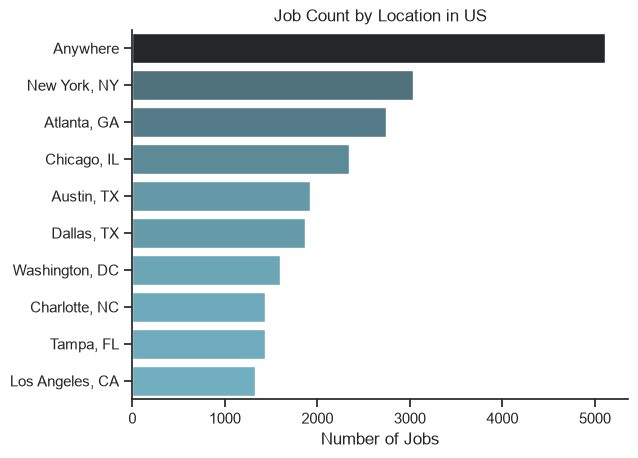

In [10]:
# Locations
top_locations = df_filtered['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot( data=top_locations , x='count' ,y='job_location' , hue='count' , palette="dark:c_r", legend=False)
sns.despine()
plt.title('Job Count by Location in US')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

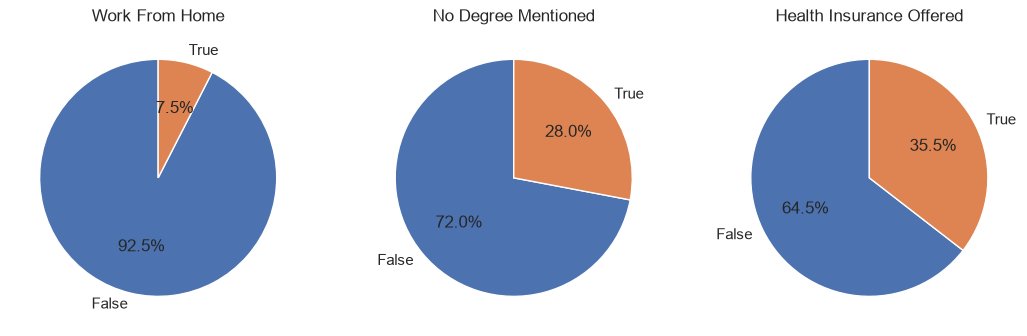

In [11]:
# Degree , Insurrance , Remote  ( boolien )

fig,ax = plt.subplots(1,3 ,figsize=(13,6))
dict_boo = {
    'job_work_from_home' : 'Work From Home' ,
    'job_no_degree_mention' : 'No Degree Mentioned',
    'job_health_insurance' :'Health Insurance Offered'  ,
}

for i,(column,title) in enumerate(dict_boo.items()) : 
    ax[i].pie(df_filtered[column].value_counts() , startangle = 90 , autopct='%1.1f%%' , labels=['False','True'])
    ax[i].set_title(title)

plt.show()


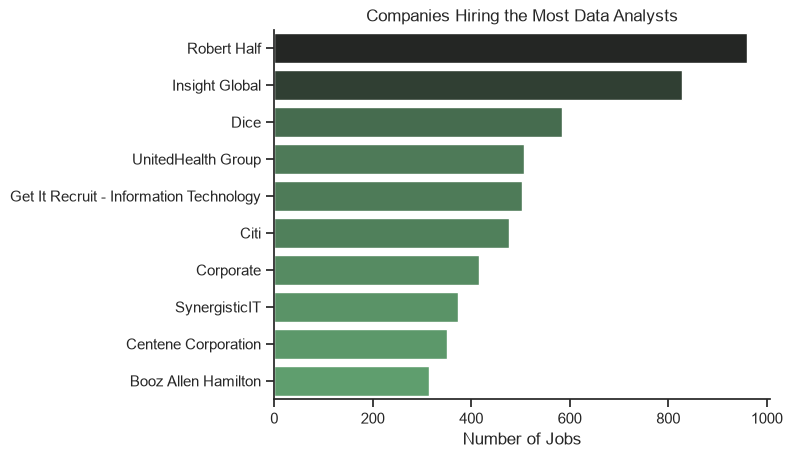

In [13]:
# Schdule job type 
companies_top_10 = df_filtered['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=companies_top_10 , x='count' , y='company_name' , hue='count' , palette='dark:g_r' , legend=False)
sns.despine()
plt.title('Companies Hiring the Most Data Analysts')
plt.ylabel('')
plt.xlabel('Number of Jobs')

plt.show()